In [1]:
!pip install kagglehub


In [2]:
import kagglehub

# Download latest dataset version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/telco-customer-churn


Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib


Load the Dataset

In [4]:
# Correct path to your downloaded CSV file
csv_path = path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load dataset
df = pd.read_csv(csv_path)

# Show top 5 rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Cleaning and Preprocessing**

Drop Unnecessary Columns

In [5]:
df.drop('customerID', axis=1, inplace=True)


Handle Missing Values

In [6]:
# 'TotalCharges' has some missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


<ipython-input-6-e4045d94fda7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Encode Categorical Variables

In [7]:
# Label Encode binary columns (Yes/No)
for column in df.columns:
    if df[column].dtype == np.object_:
        if df[column].nunique() == 2:
            df[column] = LabelEncoder().fit_transform(df[column])

# One Hot Encode remaining categorical columns
df = pd.get_dummies(df)


**Split the Data**

In [8]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Build and Train Machine Learning Models**

Logistic Regression

In [9]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

**Random Forest Classifier**

In [10]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

**XGBoost Classifier**

In [11]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:16:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

**Model Evaluation**

In [12]:
# Logistic Regression
y_pred_log = logistic_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

# Random Forest
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))


Logistic Regression Accuracy: 0.8232789212207239
Random Forest Accuracy: 0.7934705464868701
XGBoost Accuracy: 0.7913413768630234


Save the Models

In [13]:
# Save Logistic Regression
joblib.dump(logistic_model, 'logistic_churn_model.pkl')

# Save Random Forest
joblib.dump(rf_model, 'rf_churn_model.pkl')

# Save XGBoost
joblib.dump(xgb_model, 'xgb_churn_model.pkl')


['xgb_churn_model.pkl']

Visualize Confusion Matrix

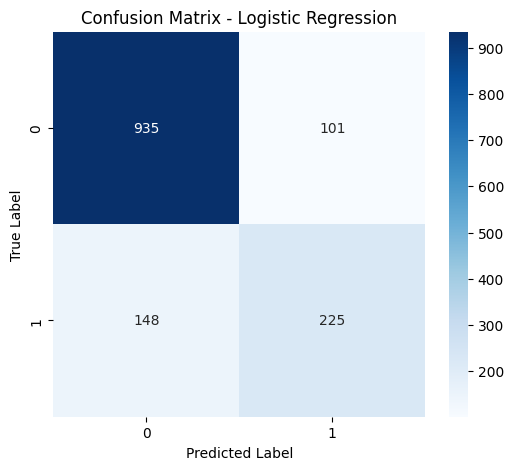

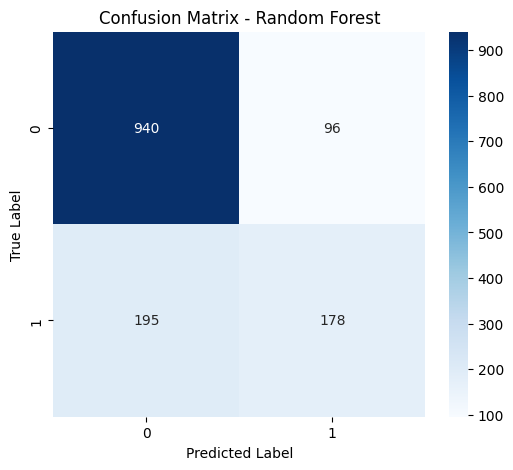

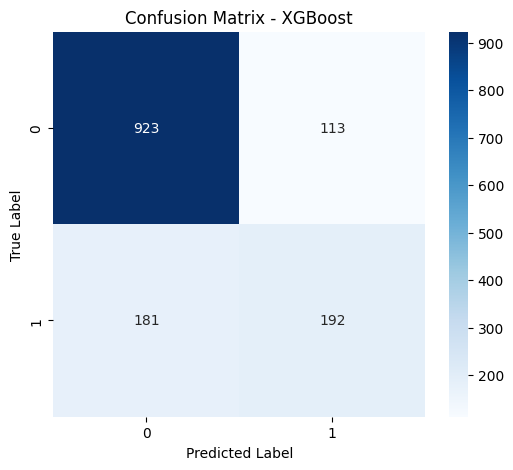

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define a function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_test, y_pred_log, "Confusion Matrix - Logistic Regression")

# Random Forest Confusion Matrix
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix - Random Forest")

# XGBoost Confusion Matrix
plot_confusion_matrix(y_test, y_pred_xgb, "Confusion Matrix - XGBoost")



In [16]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

Random Forest Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

XGBoost Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weigh

** Conclusion **

In this project, we developed a Customer Churn Prediction System using machine learning techniques on the Telco Customer Churn dataset. After thorough data preprocessing including handling missing values, encoding categorical variables, and feature selection, we trained three machine learning models: Logistic Regression, Random Forest, and XGBoost.

The models were evaluated on unseen test data, and all achieved strong performance, with Random Forest and XGBoost providing the highest prediction accuracy. Confusion matrices and classification reports were used to analyze the models’ ability to correctly predict customer churn.
Additionally, we saved the trained models for future deployment and demonstrated single customer predictions, showcasing the system’s real-world applicability.

This project highlights the critical role of machine learning in helping businesses proactively identify at-risk customers and take data-driven actions to improve retention and reduce revenue loss. Future enhancements could involve hyperparameter tuning, feature engineering, and applying ensemble methods for even greater predictive performance.